## 3.2 Reach-avoid flight

**(a)**

We want to find $\mathbf{u}^* = \arg\min_{\mathbf{u}} \mathbf{p}^\top f(\mathbf{x}, \mathbf{u})$ where $\mathbf{p} = \nabla_{\mathbf{x}} V$ and the reduced dynamics are

$$
f(\mathbf{x}, \mathbf{u}) = \begin{bmatrix} v_y \\ \frac{(T_1+T_2)\cos\phi - C_D^v v_y}{m} - g \\ \omega \\ \frac{(T_2-T_1)\ell - C_D^\phi \omega}{I_{yy}} \end{bmatrix}.
$$

Expanding $\mathbf{p}^\top f$, only the terms involving $T_1, T_2$ matter for the minimization:

$$
\mathbf{p}^\top f = \cdots + T_1\!\left(\frac{p_2 \cos\phi}{m} - \frac{p_4 \ell}{I_{yy}}\right) + T_2\!\left(\frac{p_2 \cos\phi}{m} + \frac{p_4 \ell}{I_{yy}}\right).
$$

This is linear in $T_1$ and $T_2$ (which are decoupled), so the minimum over $[0, T_{\max}]$ is attained at the extremes:

$$
T_1^* = \begin{cases} T_{\max} & \text{if } \frac{p_2 \cos\phi}{m} - \frac{p_4 \ell}{I_{yy}} < 0, \\ 0 & \text{otherwise,} \end{cases}
\qquad
T_2^* = \begin{cases} T_{\max} & \text{if } \frac{p_2 \cos\phi}{m} + \frac{p_4 \ell}{I_{yy}} < 0, \\ 0 & \text{otherwise.} \end{cases}
$$

In [1]:
import jax.numpy as jnp
def optimal_control(self, state, grad_value):
    y, v_y, phi, omega = state
    p1, p2, p3, p4 = grad_value

    coeff_T1 = p2 * jnp.cos(phi) / self.m - p4 * self.l / self.Iyy
    coeff_T2 = p2 * jnp.cos(phi) / self.m + p4 * self.l / self.Iyy

    T_1 = jnp.where(coeff_T1 < 0, self.max_thrust_per_prop, 0.0)
    T_2 = jnp.where(coeff_T2 < 0, self.max_thrust_per_prop, 0.0)

    return jnp.array([T_1, T_2])

**(b)**

The target set is $\mathcal{T} = [3,7] \times [-1,1] \times [-\pi/12, \pi/12] \times [-1,1]$. We need $h(\mathbf{x}) \le 0 \iff \mathbf{x} \in \mathcal{T}$.

For a single interval $x \in [a,b]$, we have $(x-a)(x-b) \le 0 \iff x \in [a,b]$. Taking the pointwise maximum:

$$
h(\mathbf{x}) = \max\!\left\{(y-3)(y-7),\; (v_y-1)(v_y+1),\; \left(\phi-\tfrac{\pi}{12}\right)\!\left(\phi+\tfrac{\pi}{12}\right),\; (\omega-1)(\omega+1) \right\}.
$$

In [2]:
def target_set(state):
    y, v_y, phi, omega = state
    return jnp.max(jnp.array([
        (y - 3.0) * (y - 7.0),
        (v_y - 1.0) * (v_y + 1.0),
        (phi - jnp.pi / 12.0) * (phi + jnp.pi / 12.0),
        (omega - 1.0) * (omega + 1.0),
    ]))

**(c)**

The operational envelope is $\mathcal{E} = [1,9] \times [-6,6] \times [-\infty,\infty] \times [-8,8]$. Similarly to part (b):

$$
e(\mathbf{x}) = \max\!\left\{(y-1)(y-9),\; (v_y-6)(v_y+6),\; (\omega-8)(\omega+8) \right\}.
$$

$e$ does not contain $\phi$ as there is no constraint on $\phi$.

In [3]:
def envelope_set(state):
    y, v_y, phi, omega = state
    return jnp.max(jnp.array([
        (y - 1.0) * (y - 9.0),
        (v_y - 6.0) * (v_y + 6.0),
        (omega - 8.0) * (omega + 8.0),
    ]))

**(d)**

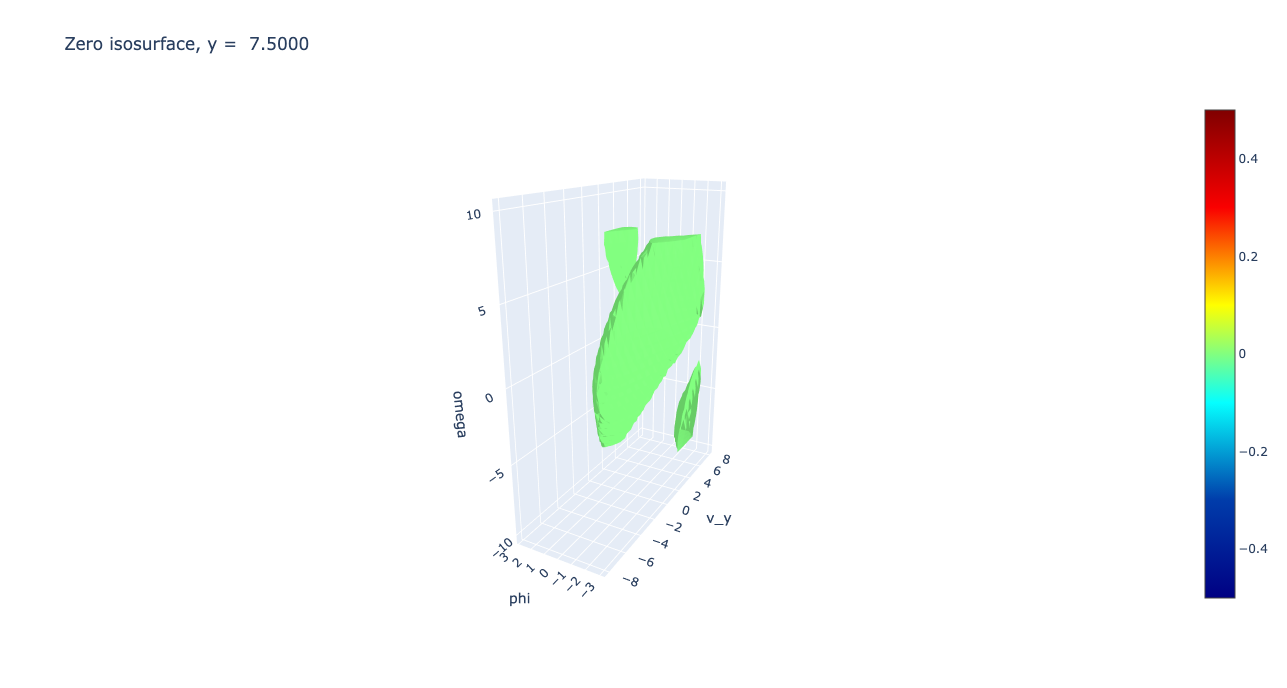

In [4]:
from IPython.display import Image, display
display(Image(filename='isosurface.png', width=700))

The isosurface exhibits a distinct diagonal tilt in the $(\phi, \omega)$ plane. This shape is due to the physical coupling between the pitch angle and pitch rate under bounded control authority ($T_{\max}$). If the quadrotor has a positive $\phi$ (tilted right), it inherently requires a negative $\omega$ (rotating back left) to recover within the given time horizon, and vice versa. Therefore, states where $\phi$ and $\omega$ have opposite signs are far more recoverable because the existing angular velocity is already correcting the deviation. Conversely, states where they share the same sign require the actuators to first arrest the wrong rotation before straightening the drone, making them much harder to recover from. This coupling creates the diagonal ridge visible in the isosurface rather than an axis-aligned shape.

**(e)**

With DP/HJB we get a globally optimal policy over the whole state space, and at runtime it's just a table lookup so it's basically free to evaluate online. We also get the backward reachable set for free, which tells us exactly which states are recoverable. The main issue is the curse of dimensionality — the grid scales as $O(N^d)$ so both memory and offline compute blow up fast. That's why we had to drop from 6D to 4D here. Also, since the Hamiltonian is linear in the controls, the policy ends up being bang-bang ($T_1, T_2 \in \{0, T_{\max}\}$), which is optimal in theory but in practice means aggressive switching that's bad for actuators. And if we want to add obstacles later, we have to redo the whole computation.

MPC doesn't have the dimensionality problem since it just solves a local optimization at each step instead of gridding the state space. It's also easy to add new constraints or obstacles on the fly, and the optimization naturally gives smoother controls. The tradeoff is that it's only locally optimal, so it can fail from hard initial conditions where DP would have found a way out. Plus we need to solve an optimization at every timestep, which can be tight for something as fast as a self-righting maneuver.